# Imports

In [67]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1.Data Preparation

### 1.1. Load Data
We are using the Handwritten Digits dataset from `sklearn` with 8x8 grayscale images flattened into 64-dimensional vectors


In [68]:
digits = load_digits() #load the dataset
X, y = digits.data, digits.target
digits.data

print(f"Total samples: {X.shape[0]}, Features: {X.shape[1]}")


Total samples: 1797, Features: 64


### 1.2. Splitting into train, validataion and test sets
The use of `stratify=y` ensures that the proportion of each digit class (0-9) is maintained across all three subsets, preventing any class imbalance bias in the evaluation.


In [69]:
X_train, X_rest, y_train, y_rest = train_test_split(X, y, train_size= 0.7, random_state=42, stratify=y) # 70% train, 30% to split again into val and test
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.50, stratify=y_rest, random_state=42) #15% validation & 15% test

print("Training set = ", X_train.shape[0])
print("Validation set = ", X_val.shape[0])
print("Test set = ", X_test.shape[0])

Training set =  1257
Validation set =  270
Test set =  270


### 1.3. Standardize the features
We standardize features (mean=0, variance=1) using `StandardScaler` which centers the data around the origin.
 
It effectively simplifies the calculation of the covariance matrix and ensures the regularization term $\lambda I$ (which adds to the diagonal) interacts consistently with the feature magnitudes.

In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (1257, 64)
Validation set: (270, 64)
Test set: (270, 64)


# 2.Gaussian Generative Model

We implement a generative classifier with the following assumptions:
1.Class Priors: $P(y=k) = \pi_k$ estimated by frequency of class $k$.
2.Class-Conditional: $P(x|y=k) \sim \mathcal{N}(\mu_k, \Sigma)$         
3.Shared Covariance: All classes share the same covariance matrix $\Sigma$.

Regularization: To ensure numerical stability, we regularize the covariance matrix: $$\Sigma_{\lambda} = \Sigma + \lambda I$$ 

Prediction Rule:
We predict the class $k$ that maximizes the log-posterior score: $$\text{score}_k = \log(\pi_k) - \frac{1}{2}(x - \mu_k)^T \Sigma_{\lambda}^{-1} (x - \mu_k)$$



In [71]:
class GaussianGenerativeClassifier:
    def __init__(self):
        self.priors = {}
        self.means = {}
        self.shared_cov = None
        self.n_features = 0
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.n_features = X.shape[1]
        n_samples = X.shape[0]
        
        
        X_centered_list = [] # Temporary list to store centered data for covariance calculation

        # 1&2. Estimate Priors and Mean
        for k in self.classes:
            X_k = X[y == k] # Samples belonging to class k
            
            self.priors[k] = X_k.shape[0] / n_samples # Prior
            self.means[k] = np.mean(X_k, axis=0) # Mean
            X_centered_list.append(X_k - self.means[k])

        # 3. Estimate Shared Covariance Matrix
        X_centered = np.vstack(X_centered_list) # Stack all centered data back together
        
        # Compute Covariance: (X_centered.T @ X_centered) / N
        self.shared_cov = np.dot(X_centered.T, X_centered) / n_samples

    def predict(self, X, lambda_reg=1e-4):
        # 4. Regularize Covariance 
        cov_reg = self.shared_cov + lambda_reg * np.eye(self.n_features) # Add lambda to the diagonal
        
        cov_inv = np.linalg.inv(cov_reg) # Pre-compute inverse for efficiency
        
        predictions = []
        
        for x in X:
            scores = {}
            for k in self.classes:
                # Get stored parameters
                mu_k = self.means[k]
                pi_k = self.priors[k]
                
                # Difference vector
                diff = x - mu_k
                
                # Mahalanobis Distance term: (x - mu)^T * Sigma^-1 * (x - mu)
                mahalanobis = np.dot(np.dot(diff.T, cov_inv), diff)
                
                # Log Score
                # score = log(prior) - 0.5 * mahalanobis_distance
                # (Ignoring the determinant term as it is constant for shared covariance)
                scores[k] = np.log(pi_k) - 0.5 * mahalanobis
            
            # Predict class with largest score [cite: 71]
            predictions.append(max(scores, key=scores.get))
            
        return np.array(predictions)

# 3.Hyperparameter Tuning
We tune the regularization parameter $\lambda$ to handle potential overfitting or ill-conditioned covariance matrices.      
- Candidates: $\lambda \in \{1e^{-4}, 1e^{-3}, 1e^{-2}, 1e^{-1}\}$.

In [72]:
lambda_candidates = [1e-4, 1e-3, 1e-2, 1e-1]
results = []
best_acc = 0
best_lambda = None

model = GaussianGenerativeClassifier()
model.fit(X_train_scaled, y_train)

print(f"{'Lambda':<10} | {'Val Accuracy':<15}")
print("-" * 30)

for lam in lambda_candidates:
    y_pred_val = model.predict(X_val_scaled, lambda_reg=lam)
    
    # Calculate accuracy
    acc = accuracy_score(y_val, y_pred_val)
    results.append({'Lambda': lam, 'Val Accuracy': acc})
    
    print(f"{lam:<10} | {acc:.4f}")
    
    # Track best lambda
    if acc > best_acc:
        best_acc = acc
        best_lambda = lam

print("-" * 30)
print(f"Best Lambda: {best_lambda} with Accuracy: {best_acc:.4f}")

Lambda     | Val Accuracy   
------------------------------
0.0001     | 0.9444
0.001      | 0.9444
0.01       | 0.9444
0.1        | 0.9444
------------------------------
Best Lambda: 0.0001 with Accuracy: 0.9444


# 4. Final Model Training


Final Test Set Performance:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.8667    0.9286    0.8966        28
           2     1.0000    1.0000    1.0000        26
           3     1.0000    1.0000    1.0000        28
           4     1.0000    1.0000    1.0000        27
           5     0.9643    1.0000    0.9818        27
           6     1.0000    1.0000    1.0000        27
           7     0.9643    1.0000    0.9818        27
           8     0.9167    0.8462    0.8800        26
           9     0.9200    0.8519    0.8846        27

    accuracy                         0.9630       270
   macro avg     0.9632    0.9627    0.9625       270
weighted avg     0.9630    0.9630    0.9625       270



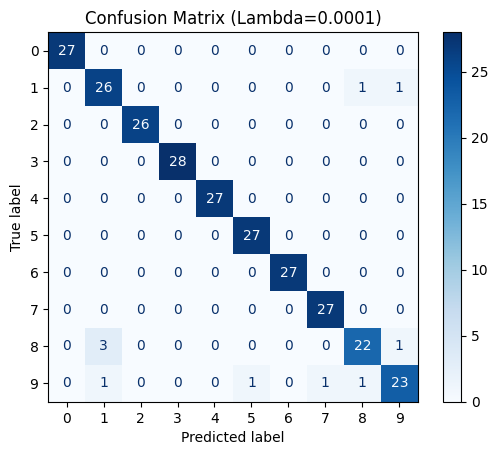

In [73]:
# Combine Train and Validation sets
X_final_train = np.vstack((X_train_scaled, X_val_scaled))
y_final_train = np.hstack((y_train, y_val))

final_model = GaussianGenerativeClassifier()
final_model.fit(X_final_train, y_final_train)

y_pred_test = final_model.predict(X_test_scaled, lambda_reg=best_lambda)

print("\nFinal Test Set Performance:")
print(classification_report(y_test, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Lambda={best_lambda})")
plt.show()